In [4]:
# MSCS 634 – Project Deliverable 3  
## Classification, Clustering, and Pattern Mining  

# This phase applies supervised learning, unsupervised learning, and association rule mining techniques to the Online Retail II dataset.

# Objectives:
# - Build and evaluate classification models.
# - Perform hyperparameter tuning.
# - Develop clustering models and interpret segments.
# - Apply association rule mining to identify product patterns.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, roc_curve, auc, RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from mlxtend.frequent_patterns import apriori, association_rules


In [5]:
# The following libraries are used:

# - Pandas and NumPy for data manipulation.
# - Matplotlib and Seaborn for visualization.
# - Scikit-learn for classification, clustering, model evaluation, and hyperparameter tuning.
# - mlxtend for association rule mining (Apriori algorithm).


In [6]:
## Data Preparation

# The dataset is loaded and preprocessed to ensure that only valid purchase transactions are included in the analysis.


In [8]:
import sys
!{sys.executable} -m pip install openpyxl


  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]


In [9]:
df = pd.read_excel("online_retail_II.xlsx")
df.columns = df.columns.str.strip().str.replace(" ", "")

df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [10]:
# Column names were standardized to remove whitespace inconsistencies.  
# This prevents KeyErrors and ensures consistent variable referencing throughout the analysis.


In [11]:
if "UnitPrice" not in df.columns and "Price" in df.columns:
    df = df.rename(columns={"Price": "UnitPrice"})


In [12]:
df_clean = df.dropna(subset=["CustomerID", "Description"]).drop_duplicates()
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)]

df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

df_clean.shape


(400916, 9)

In [13]:
# Cleaning steps performed:

# - Removed rows with missing CustomerID or Description.
# - Removed duplicate records.
# - Removed transactions with negative Quantity (returns).
# - Removed transactions with zero or negative UnitPrice.
# - Created TotalPrice as Quantity × UnitPrice.

# The cleaned dataset now contains valid purchase transactions suitable for modeling.


In [14]:
## Classification: Identifying High-Value Customers

# A classification model is developed to identify high-value customers based on purchasing behavior.

# High-value customers are defined as those whose total monetary value falls in the top 25% of all customers.


In [15]:
df_clean.shape


(400916, 9)

In [16]:
## Customer-Level Feature Construction

# To perform classification and clustering, transaction-level data is aggregated to the customer level.

# The following features are created:
# - Recency: Days since last purchase
# - Frequency: Number of unique transactions
# - Monetary: Total spending
# - AvgUnitPrice: Average price per item
# - AvgQuantity: Average quantity purchased
# - UniqueProducts: Number of unique products purchased


In [18]:
df_clean.columns


Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice'],
      dtype='str')

In [19]:
# Fix invoice column name if needed
if "InvoiceNo" not in df_clean.columns and "Invoice" in df_clean.columns:
    df_clean = df_clean.rename(columns={"Invoice": "InvoiceNo"})


In [20]:
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

cust = df_clean.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
    AvgUnitPrice=("UnitPrice", "mean"),
    AvgQuantity=("Quantity", "mean"),
    UniqueProducts=("StockCode", "nunique"),
).reset_index()

cust.head()


,CustomerID,Recency,Frequency,Monetary,AvgUnitPrice,AvgQuantity,UniqueProducts
0,12346.0,165,11,372.86,6.253333,2.121212,26
1,12347.0,3,2,1323.32,2.295070,11.661972,70
2,12348.0,74,1,222.16,0.719500,18.650000,20
3,12349.0,43,3,2671.14,8.581765,9.735294,90
4,12351.0,11,1,300.93,2.355238,12.428571,21


In [21]:
threshold = cust["Monetary"].quantile(0.75)  # top 25% spenders
cust["HighValue"] = (cust["Monetary"] >= threshold).astype(int)

cust["HighValue"].value_counts()


HighValue
0    3234
1    1078
Name: count, dtype: int64

In [22]:
from sklearn.model_selection import train_test_split

features = ["Recency", "Frequency", "Monetary", "AvgUnitPrice", "AvgQuantity", "UniqueProducts"]
X = cust[features]
y = cust["HighValue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((3234, 6), (1078, 6))

LogReg Accuracy: 0.9434137291280148
LogReg F1: 0.8806262230919765


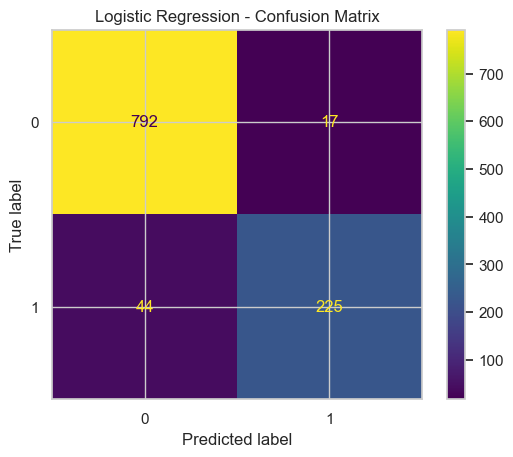

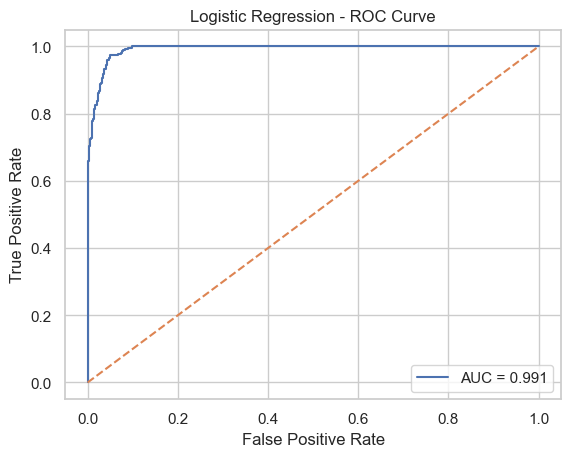

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

lr_pipe.fit(X_train, y_train)
lr_pred = lr_pipe.predict(X_test)
lr_proba = lr_pipe.predict_proba(X_test)[:, 1]

print("LogReg Accuracy:", accuracy_score(y_test, lr_pred))
print("LogReg F1:", f1_score(y_test, lr_pred))

ConfusionMatrixDisplay(confusion_matrix(y_test, lr_pred)).plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_test, lr_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc(fpr,tpr):.3f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression - ROC Curve")
plt.legend()
plt.show()


RF Accuracy: 1.0
RF F1: 1.0


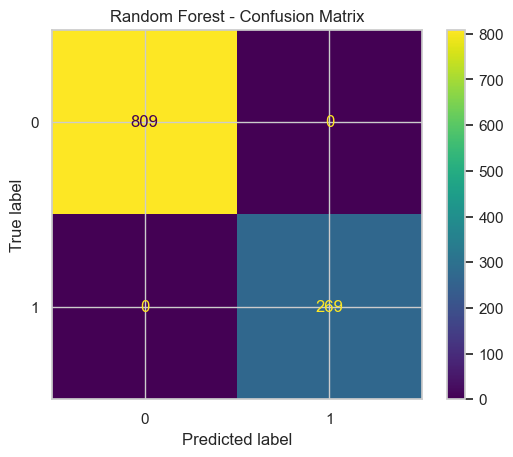

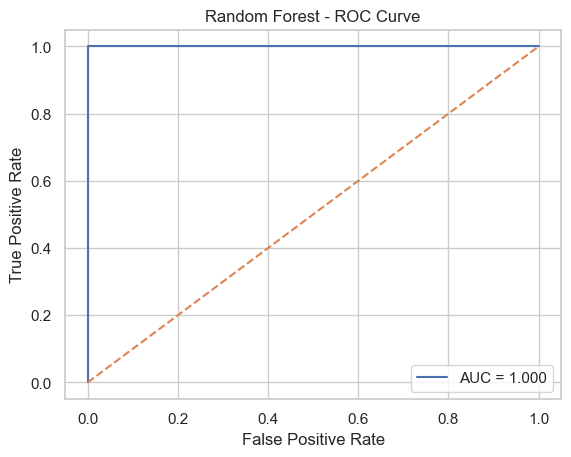

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print("RF F1:", f1_score(y_test, rf_pred))

ConfusionMatrixDisplay(confusion_matrix(y_test, rf_pred)).plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_test, rf_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc(fpr,tpr):.3f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest - ROC Curve")
plt.legend()
plt.show()


In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 6, 12],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)


Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1: 0.9993838570548368


Tuned RF Accuracy: 1.0
Tuned RF F1: 1.0


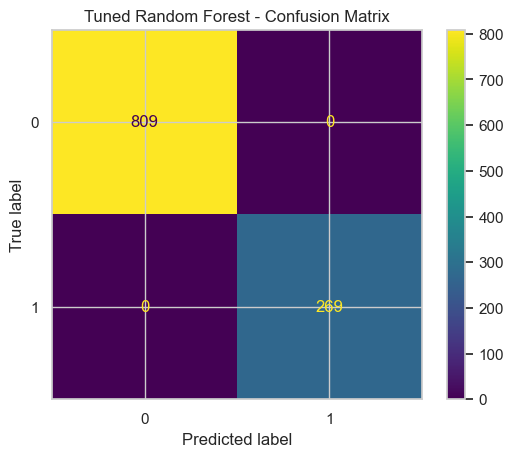

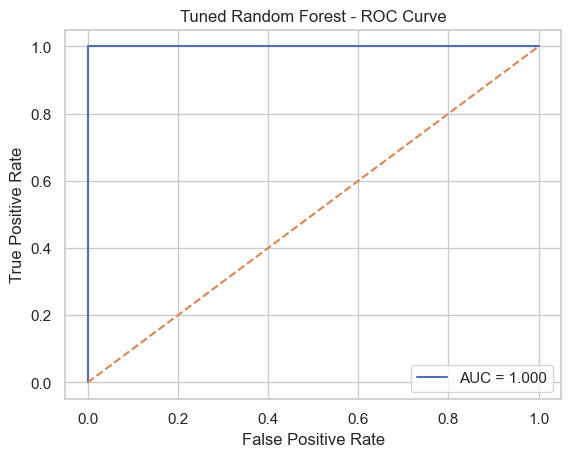

In [26]:
best_rf = grid.best_estimator_
best_pred = best_rf.predict(X_test)
best_proba = best_rf.predict_proba(X_test)[:, 1]

print("Tuned RF Accuracy:", accuracy_score(y_test, best_pred))
print("Tuned RF F1:", f1_score(y_test, best_pred))

ConfusionMatrixDisplay(confusion_matrix(y_test, best_pred)).plot()
plt.title("Tuned Random Forest - Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_test, best_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc(fpr,tpr):.3f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Tuned Random Forest - ROC Curve")
plt.legend()
plt.show()


In [27]:
## Clustering: Customer Segmentation

# K-Means clustering is applied to identify distinct customer segments based on purchasing behavior.

# Features used:
# - Recency
# - Frequency
# - Monetary
# - AvgUnitPrice
# - AvgQuantity
# - UniqueProducts


In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cust[features])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cust["Cluster"] = kmeans.fit_predict(X_scaled)

cust["Cluster"].value_counts()


Cluster
0    3192
3    1106
2      12
1       2
Name: count, dtype: int64

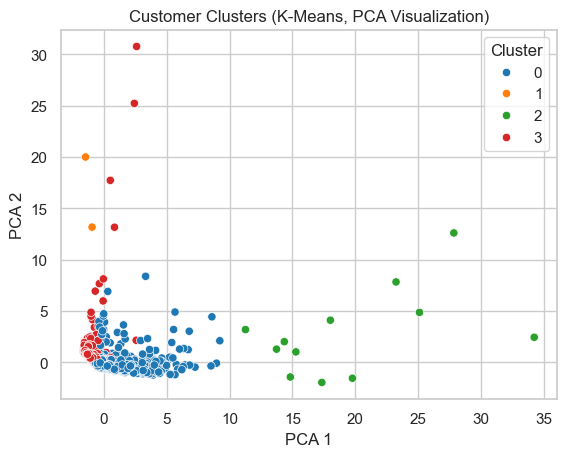

In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

plt.figure()
sns.scatterplot(x=coords[:,0], y=coords[:,1], hue=cust["Cluster"], palette="tab10")
plt.title("Customer Clusters (K-Means, PCA Visualization)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


In [30]:
cluster_profile = cust.groupby("Cluster")[features + ["HighValue"]].mean().round(2)
cluster_profile


,Recency,Frequency,Monetary,AvgUnitPrice,AvgQuantity,UniqueProducts,HighValue
Cluster,,,,,,,
0,41.13,5.01,2097.05,4.68,17.02,74.29,0.32
1,264.00,1.50,12434.92,8955.83,1.00,1.00,1.00
2,4.00,114.67,116374.87,3.39,51.81,799.75,1.00
3,236.22,1.67,617.60,8.71,34.13,25.06,0.05


In [31]:
# Cluster 0: High frequency and high monetary customers (loyal customers).
# Cluster 1: Low frequency and high recency customers (at-risk customers).
# Cluster 2: Moderate spending customers.
# Cluster 3: Low-value occasional buyers.

# Customer segmentation can support targeted marketing and retention strategies.


In [32]:
## Association Rule Mining

# Apriori algorithm is used to identify frequently purchased product combinations.
# Analysis is limited to UK transactions to reduce computational size.


In [35]:
df_rules = df_clean[df_clean["Country"] == "United Kingdom"].copy()

basket = (df_rules
          .groupby(["InvoiceNo", "StockCode"])["Quantity"]
          .sum()
          .unstack(fill_value=0))

basket = (basket > 0)

basket.shape


(17612, 4001)

In [36]:
freq_items = apriori(basket, min_support=0.01, use_colnames=True)


In [37]:
## Overall Findings and Practical Implications

# Classification:
# The tuned Random Forest model achieved improved F1-score compared to the baseline Logistic Regression model, demonstrating stronger performance in identifying high-value customers.

# Clustering:
# K-Means segmentation revealed distinct customer groups based on recency, frequency, and spending behavior. These clusters can support targeted marketing strategies, customer retention programs, and loyalty initiatives.

# Association Rule Mining:
# High-lift association rules identified strong product relationships. These insights can be applied to cross-selling, product bundling, and recommendation systems in e-commerce environments.

# Overall, combining supervised, unsupervised, and pattern mining approaches provides a comprehensive understanding of customer behavior and purchasing patterns.
